In [2]:
import os 
import numpy as np

n = 10
m = 40

In [3]:
# Load data
file_path = f"data/generated_qp_data_10v_40c.npz"
if os.path.exists(file_path):
    data = np.load(file_path, allow_pickle=True)
    H = data["H"]
    f = data["f"]
    F = data["F"]
    A = data["A"]
    b = data["b"]
    B = data["B"]

print(H.shape,f.shape,F.shape,A.shape,b.shape,B.shape)

(10, 10) (10,) (10, 2) (40, 10) (40,) (40, 2)


In [4]:
# Load data
file_path = f"data/generated_qp_data_10v_40c_flex_H.npz"
if os.path.exists(file_path):
    data = np.load(file_path, allow_pickle=True)
    H1 = data["H"]
    f1 = data["f"]
    F1 = data["F"]
    A1 = data["A"]
    b1 = data["b"]
    B1 = data["B"]

print(H1.shape,f1.shape,F1.shape,A1.shape,b1.shape,B1.shape)

(10, 10) (10,) (10, 2) (40, 10) (40,) (40, 2)


In [7]:

print(A1[-1,-1])
print(A[-1,-1])


1.1144819422483456
0.585768138667071


In [41]:
%load_ext autoreload
%autoreload 2

# Calculate the percentage of active constraints in the training and validation sets for [10]v,[40c] data


from generate_graph_data import generate_qp_graphs_train_val,generate_qp_graphs_train_val_lmpc
import numpy as np
from ctypes import * 


n = [10]
m = [40]
nth = 2
seed_vector = [123,124,125,126,127]
lr = 0.001
number_of_max_epochs = 100
layer_width = 128
number_of_layers = 3
track_on_wandb = False
runs = 5
layer_width = 128
data_points = 2000
t = 0.8 # threshold 
for i in range(runs):
    print(i)
    n_i = n[0]
    m_i = m[0]
    seed = seed_vector[i]
    H_flexible = False
    A_flexible = False
    modelname = "model_10v_40c_test"
    scale_H=1
    dataset_type="standard"
    conv_type="LEConv"
    two_sided = False
    cuda = 0
    sparsity ="dense"
    relu_slope = 0.1
    graph_train_i, graph_val_i = generate_qp_graphs_train_val(n_i,m_i,nth,seed,data_points,H_flexible=H_flexible,A_flexible=A_flexible,sparsity=sparsity)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
0
dense
10 40 2
(10, 10) (10,) (10, 2) (40, 10) (40,) (40, 2) (10, 2)
condition number of H 4170.536480869921
Done generating train data
Average number of active constraints in train set 0.21235937500000002
Average number of active constraints in val set 0.21262500000000004
1
dense
10 40 2
(10, 10) (10,) (10, 2) (40, 10) (40,) (40, 2) (10, 2)
condition number of H 2749.9990859498566
Done generating train data
Average number of active constraints in train set 0.222890625
Average number of active constraints in val set 0.22187500000000004
2
dense
10 40 2
(10, 10) (10,) (10, 2) (40, 10) (40,) (40, 2) (10, 2)
condition number of H 62.31556697011391
Done generating train data
Average number of active constraints in train set 0.21125000000000005
Average number of active constraints in val set 0.212
3
dense
10 40 2
(10, 10) (10,) (10, 2) (40, 10) (40,) (40, 2) (10, 2)
condition number of H 1767.49261757550

In [ ]:
# Calculate the percentage of active constraints in the training and validation sets for lmpc data
n = [5]
m = [206]
nth = 7
seed = 123
data_points = 2000
lr = 0.001
number_of_max_epochs = 100
layer_width = 128
number_of_layers = 3
track_on_wandb = False #True
t = 0.5
scale = 0.01
runs = 5
model_name = f"model_{n[0]}v_{m[0]}c_lmpc_R_00001_avg"
cuda = 0
for i in range(runs):
    print(i)
    n_i = n[0]
    m_i = m[0]
    seed = seed_vector[i]
    H_flexible = False
    A_flexible = False
    modelname = "model_lmpc_test"
    scale_H=1
    dataset_type="standard"
    conv_type="LEConv"
    two_sided = False
    cuda = 0
    sparsity ="dense"
    relu_slope = 0.1

    graph_train_i, graph_val_i = generate_qp_graphs_train_val_lmpc(n_i,m_i,nth,seed,data_points,scale=scale_H,two_sided=two_sided)

0
scale 1
(5, 5) (5, 1) (5, 7) (206, 5) (206,) (206, 7)
Average number of active constraints in train set 0.0183131067961165
Average number of active constraints in val set 0.018082524271844657
1
scale 1
(5, 5) (5, 1) (5, 7) (206, 5) (206,) (206, 7)
Average number of active constraints in train set 0.01786407766990291
Average number of active constraints in val set 0.01827669902912621
2
scale 1
(5, 5) (5, 1) (5, 7) (206, 5) (206,) (206, 7)
Average number of active constraints in train set 0.018015776699029123
Average number of active constraints in val set 0.01740291262135922
3
scale 1
(5, 5) (5, 1) (5, 7) (206, 5) (206,) (206, 7)
Average number of active constraints in train set 0.01804308252427184
Average number of active constraints in val set 0.01800970873786407
4
scale 1
(5, 5) (5, 1) (5, 7) (206, 5) (206,) (206, 7)
Average number of active constraints in train set 0.018079490291262133
Average number of active constraints in val set 0.018567961165048538


: 

In [ ]:
from naive_model import naive_model 

naive_model(n_vector,m_vector,all_labels)

In [8]:
import daqp
from naive_model import naive_model

# Load the data
file_path = "data/generated_qp_data_10v_40c.npz"
data = np.load(file_path, allow_pickle=True)
H = data["H"]
f = data["f"]
F = data["F"]
A = data["A"]
b = data["b"]
B = data["B"]
T = data["T"]

n = 10
m = 40
nth = T.shape[1]
number_of_graphs = 10  # Number of test graphs to generate

all_labels = []
n_vector = []
m_vector = []

for i in range(number_of_graphs):
    theta = np.random.randn(nth)
    btot = b + B @ theta
    ftot = f + F @ theta
    
    sense = np.zeros(m, dtype=np.int32)
    blower = np.array([-np.inf for _ in range(m)])
    
    _, _, _, info = daqp.solve(H, ftot, A, btot, blower, sense)
    lambda_i = list(info.values())[4]  # lambda
    active_set = (lambda_i != 0).astype(int)
    y = np.hstack((np.zeros(n), active_set))
    all_labels.extend(y)
    n_vector.append(n)
    m_vector.append(m)

# Call naive_model
acc, prec, rec, f1, perc_wrongly_pred_nodes_per_graph, correctly_predicted_graphs, pr_auc = naive_model(n_vector, m_vector, all_labels)

print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1 Score: {f1}")
print(f"Percentage wrongly predicted nodes per graph: {perc_wrongly_pred_nodes_per_graph}")
print(f"Correctly predicted graphs: {correctly_predicted_graphs}")
print(f"PR AUC: {pr_auc}")

Accuracy: 0.838
Precision: 0
Recall: 0.0
F1 Score: 0
Percentage wrongly predicted nodes per graph: [[np.float64(0.12)], [np.float64(0.1)], [np.float64(0.18)], [np.float64(0.14)], [np.float64(0.16)], [np.float64(0.2)], [np.float64(0.18)], [np.float64(0.18)], [np.float64(0.18)], [np.float64(0.18)]]
Correctly predicted graphs: 0
PR AUC: 0.581


In [10]:
import daqp
from naive_model import naive_model

# Load the data
file_path = "data/generated_qp_data_10v_40c_flex_H.npz"
data = np.load(file_path, allow_pickle=True)
H = data["H"]
f = data["f"]
F = data["F"]
A = data["A"]
b = data["b"]
B = data["B"]
T = data["T"]

n = 10
m = 40
nth = T.shape[1]
number_of_graphs = 10  # Number of test graphs to generate

all_labels = []
n_vector = []
m_vector = []

for i in range(number_of_graphs):
    theta = np.random.randn(nth)
    btot = b + B @ theta
    ftot = f + F @ theta
    
    sense = np.zeros(m, dtype=np.int32)
    blower = np.array([-np.inf for _ in range(m)])
    
    _, _, _, info = daqp.solve(H, ftot, A, btot, blower, sense)
    lambda_i = list(info.values())[4]  # lambda
    active_set = (lambda_i != 0).astype(int)
    y = np.hstack((np.zeros(n), active_set))
    all_labels.extend(y)
    n_vector.append(n)
    m_vector.append(m)

# Call naive_model
acc, prec, rec, f1, perc_wrongly_pred_nodes_per_graph, correctly_predicted_graphs, pr_auc = naive_model(n_vector, m_vector, all_labels)

print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1 Score: {f1}")
print(f"Percentage wrongly predicted nodes per graph: {perc_wrongly_pred_nodes_per_graph}")
print(f"Correctly predicted graphs: {correctly_predicted_graphs}")
print(f"PR AUC: {pr_auc}")

Accuracy: 0.818
Precision: 0
Recall: 0.0
F1 Score: 0
Percentage wrongly predicted nodes per graph: [[np.float64(0.2)], [np.float64(0.16)], [np.float64(0.18)], [np.float64(0.2)], [np.float64(0.2)], [np.float64(0.18)], [np.float64(0.18)], [np.float64(0.2)], [np.float64(0.18)], [np.float64(0.14)]]
Correctly predicted graphs: 0
PR AUC: 0.591


max val: 20.0, min val: 1.0


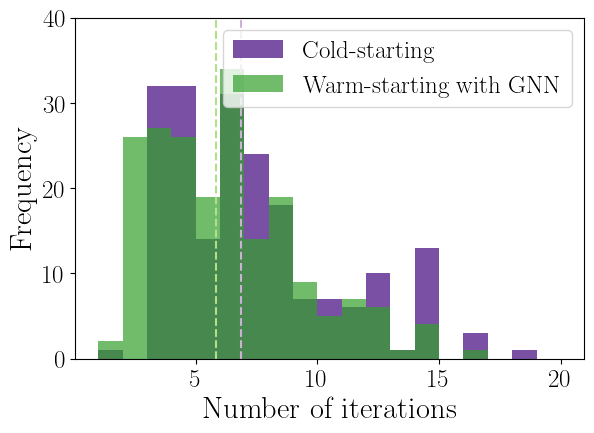

max val: 123.0, min val: 1.0


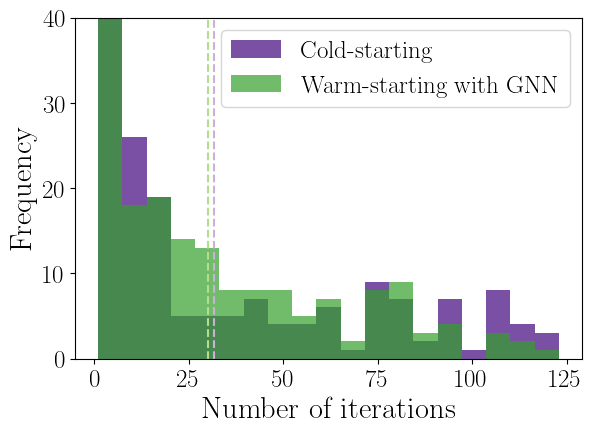

In [1]:
import pickle
from utils import barplot_iterations, histogram_time, histogram_prediction_time, barplot_iter_reduction,histogram_iterations
import matplotlib.pyplot as plt

# Set parameters
n = [5]
m = [206]
nth = 7
seed = 123
data_points = 200#0
lr = 0.001
number_of_max_epochs = 100
layer_width = 128
number_of_layers = 3
track_on_wandb = False #True
t = 0.5
scale = 0.01
runs = 1 #5
model_name = f"model_{n[0]}v_{m[0]}c_lmpc_R_00001_avg"
cuda = 0


# Load data
with open("./data/lmpc_experiment_5v_206c_server.pkl", "rb") as f:
    parameters, test_time_before_avg,test_time_after_avg,test_iterations_before_avg,test_iterations_after_avg,test_iterations_diff_avg = pickle.load(f)


# Plot average results
#histogram_time(test_time_before_avg, test_time_after_avg, f"{model_name}_test", save=False)
histogram_iterations(test_iterations_before_avg, test_iterations_after_avg, f"{model_name}_test", save=False)

with open("./data/lmpc_experiment_50v_296c_t_05.pkl", "rb") as f:
    parameters, test_time_before_avg,test_time_after_avg,test_iterations_before_avg,test_iterations_after_avg,test_iterations_diff_avg = pickle.load(f)
histogram_iterations(test_iterations_before_avg, test_iterations_after_avg, f"{model_name}_test", save=False)
